# GPSolver and Hyperparameter Optimization

This notebook fits GP hyperparameters to a simulated stellar lightcurve using
`GPSolver`. It continues from `trapezoid_symmetric_tutorial.ipynb`, which
builds the model and generates the lightcurve.

1. **Set up** the model and simulate a lightcurve (quick recap)  
2. **Warm up JAX** with `build_jax()` for `AnalyticKernel` and `GPSolver`  
3. **Single-start MAP** fit with `fit_map()`  
4. **Multi-start MAP** to avoid local minima  

In [1]:
import sys
sys.path.append("../..")

import time
import numpy as np
import matplotlib.pyplot as plt

from src_jax import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    LightcurveModel,
    AnalyticKernel,
    GPSolver,
)

np.random.seed(42)

---
## 1. Model setup and lightcurve simulation

Reproduce the `SpotEvolutionModel` and synthetic lightcurve from the envelope tutorial.

In [2]:
envelope = TrapezoidSymmetricEnvelope(lspot=14.0, tau_spot=6.0)
visibility = VisibilityFunction(peq=4.0, kappa=0.3, inc=np.pi / 3)
model = SpotEvolutionModel(envelope=envelope, visibility=visibility, sigma_k=0.01)

print("param_keys:", model.param_keys)

param_keys: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'sigma_k')


In [3]:
lc = LightcurveModel.from_spot_model(
    spot_model=model,
    nspot=30,
    tsim=150,
    tsamp=1.0,
    lat=[-np.pi / 2, np.pi / 2],
    long=[0, 2 * np.pi],
)

sigma_n = 0.3 * np.std(lc.flux)
flux_obs = lc.flux + np.random.normal(0, sigma_n, lc.flux.shape)
flux_err = np.full_like(flux_obs, sigma_n)
tobs = lc.t

print(f"Lightcurve: {len(tobs)} points, sigma_n = {sigma_n:.5f}")

Lightcurve: 150 points, sigma_n = 0.00164


---
## 2. Warm up JAX with `build_jax()`

Call `build_jax()` on both `AnalyticKernel` and `GPSolver` before any timed
operations. This pays the XLA compilation cost upfront so subsequent calls
reflect true runtime.

| Class | What gets compiled |
|---|---|
| `AnalyticKernel` | `kernel()` and `compute_psd()` |
| `GPSolver` | `log_posterior`, `neg_log_posterior`, `grad_log_posterior`, `grad_neg_log_posterior` |

In [5]:
ak = AnalyticKernel(model).build_jax()

JAX kernel compiled in 3.57s
JAX kernel recompute in 0.24s


---
## 3. GP hyperparameter fit — MAP solution

Construct a `GPSolver` from the `SpotEvolutionModel`, define bounds,
call `build_jax()` to compile all four JIT functions, then run `fit_map()`.

In [4]:
bounds = {
    "peq":         (5.0, 10.0),
    "kappa":       (-0.5, 0.8),
    "inc":         (0.1, np.pi / 2),
    "lspot":       (2.0, 20.0),
    "tau_spot":    (0.5, 10.0),
    "log_sigma_k": (-4.0, 0.0),   # sample sigma_k in log10 space
}

# Pass the SpotEvolutionModel directly — GPSolver reads param_keys from it
gp = GPSolver(tobs, flux_obs, flux_err, model, bounds=bounds)

print("param_keys:", gp.param_keys)
print("n_params  :", gp.n_params)
print("bandwidth :", gp.bandwidth)

Banded Cholesky: bandwidth=40, N=150, sparsity=72.7%
param_keys: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'log_sigma_k')
n_params  : 6
bandwidth : 40


We can also check what the structure of the covariance matrix by plotting it. This function can be slow to plot large matrices, so we will bin down the matrix to a `nbin` by `nbin` grid. Note: the sparsity bandwidth is set by the upper limit of `lspot` and `tau_spot` from the bounds.

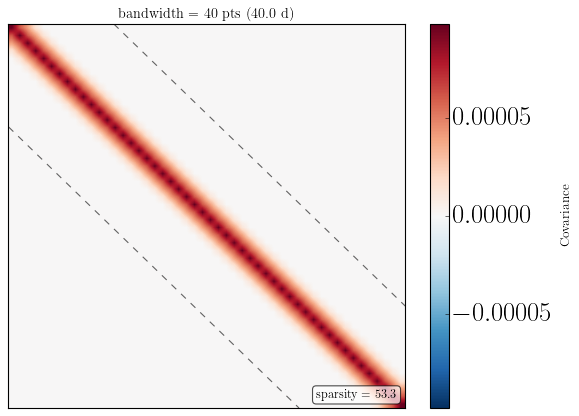

<Axes: title={'center': 'bandwidth = 40 pts (40.0 d)'}>

In [5]:
gp.plot_covariance_matrix(show=True, nbins=50)

In [6]:
# Compile all four JIT functions (log_posterior, neg_log_posterior,
# grad_log_posterior, grad_neg_log_posterior) before timing any fits.
#
# Without build_jax(), the first call to fit_map() would silently
# include several seconds of XLA compilation time.
gp = gp.build_jax()

JAX GP solver compiled in 3.67s
JAX GP solver recompute in 0.07s


In [7]:
t0 = time.time()
theta_map, opt_result = gp.fit_map(method="nelder-mead")
print(f"fit_map() wall time: {time.time() - t0:.2f} s  "
      f"(converged: {opt_result.success})")

# True values for comparison
theta_true = {
    "peq":      model.peq,
    "kappa":    model.kappa,
    "inc":      model.inc,
    "lspot":    model.lspot,
    "tau_spot": model.tau_spot,
    "sigma_k":  model.sigma_k,
}

print(f"\n{'param':>12s}  {'true':>10s}  {'MAP':>10s}")
print("-" * 38)
for k, v_true in theta_true.items():
    v_map = theta_map.get(k, theta_map.get("log_" + k, float("nan")))
    print(f"{k:>12s}  {v_true:10.4f}  {v_map:10.4f}")

fit_map() wall time: 29.37 s  (converged: False)

       param        true         MAP
--------------------------------------
         peq      4.0000      5.0054
       kappa      0.3000      0.7769
         inc      1.0472      1.5505
       lspot      8.0000     11.7706
    tau_spot      3.0000      0.5528
     sigma_k      0.0100     -2.3722


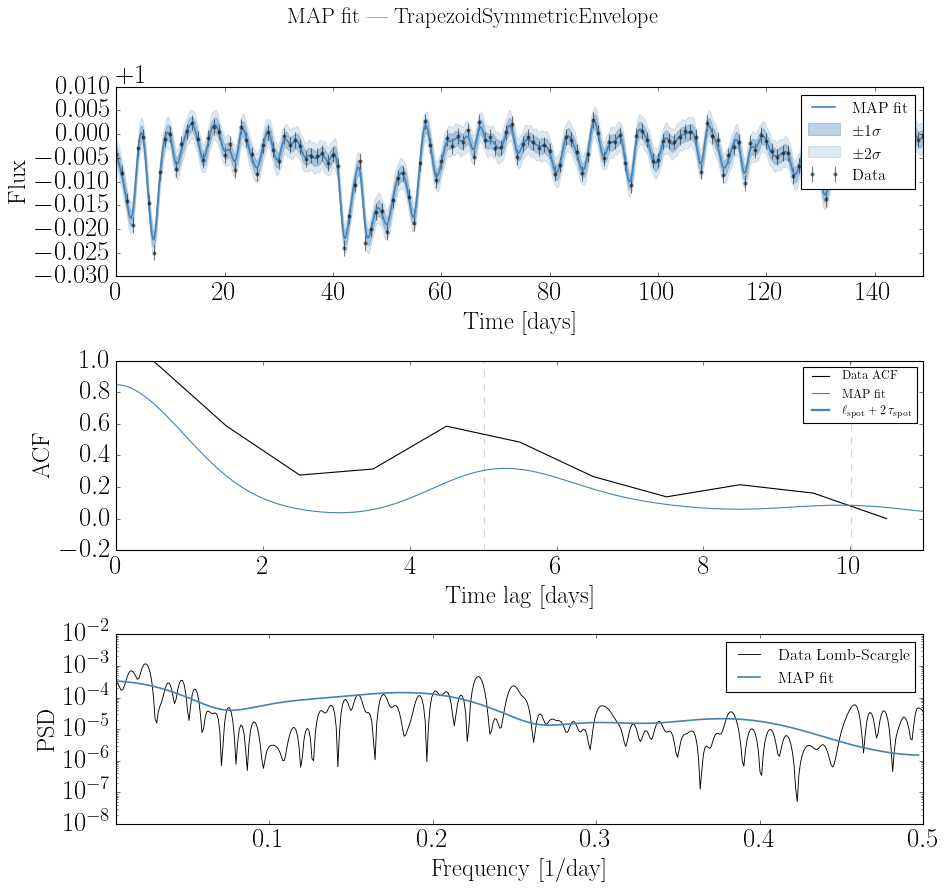

In [11]:
tlag_plot = np.arange(0, 3 * model.peq, lc.tsamp)

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

gp.plot_prediction(theta=theta_map, ax=axes[0],
                   model_color="steelblue", model_label="MAP fit")

gp.plot_acf(theta=theta_map, ax=axes[1], tlags=tlag_plot,
            model_color="steelblue", model_label="MAP fit",
            normalize=True)
# Mark rotation period and envelope support
t_env = theta_map["lspot"] + 2 * theta_map["tau_spot"]
for n in range(int(t_env / theta_map["peq"]) + 1):
    axes[1].axvline(n * theta_map["peq"], color="steelblue", alpha=0.3, lw=1, ls="--")
axes[1].axvline(t_env, color="steelblue", lw=2,
                label=r"$\ell_{\rm spot} + 2\,\tau_{\rm spot}$")
axes[1].legend(fontsize=11)

gp.plot_psd(theta=theta_map, ax=axes[2],
            model_color="steelblue", model_label="MAP fit")

fig.suptitle("MAP fit — TrapezoidSymmetricEnvelope", fontsize=20, y=1.01)
fig.tight_layout()
plt.show()

---
## 4. Multi-start MAP (optional)

MAP optimization can land in local minima. Run several trials from random
starting points and keep the best. `fit_map(nopt=N)` handles this automatically —
**compile once with `build_jax()` first**.

In [12]:
t0 = time.time()
theta_best, opt_best = gp.fit_map(nopt=5, method="nelder-mead")
print(f"5-start fit_map() wall time: {time.time() - t0:.2f} s")

print(f"\n{'param':>12s}  {'true':>10s}  {'MAP (best)':>12s}")
print("-" * 42)
for k, v_true in theta_true.items():
    v_map = theta_best.get(k, theta_best.get("log_" + k, float("nan")))
    print(f"{k:>12s}  {v_true:10.4f}  {v_map:12.4f}")

5-start fit_map() wall time: 151.89 s

       param        true    MAP (best)
------------------------------------------
         peq      4.0000        5.0195
       kappa      0.3000       -0.3981
         inc      1.0472        1.1160
       lspot      8.0000        9.0598
    tau_spot      3.0000        0.5302
     sigma_k      0.0100       -2.4003
